In [1]:
import warnings, logging
warnings.filterwarnings("ignore")
logging.getLogger().setLevel(logging.ERROR)

from IPython.display import display

import os
import argparse
from pathlib import Path

from itertools import combinations_with_replacement

import math
import pandas as pd
import numpy as np
import anndata as ad
import scanpy as sc
import bonesistools as bt

from goatools.obo_parser import GODag
from goatools.anno.gaf_reader import GafReader
from goatools.anno.genetogo_reader import Gene2GoReader
from goatools.goea.go_enrichment_ns import GOEnrichmentStudyNS

import mpbn

import matplotlib.pyplot as plt

bt.sct.pl.set_default_params()

In [2]:
genesyn = bt.dbs.ncbi.GeneSynonyms(organism="mouse")

In [3]:
bn = mpbn.MPBooleanNetwork.load("data/hematopoiesis/min.bnet")
study_ids = genesyn(
    list(bn),
    input_identifier_type="name",
    output_identifier_type="gene_id"
)
study_ids = set(map(lambda gene_id: int(gene_id) if gene_id.isnumeric() else None, study_ids))
study_ids.discard(None)

grn = bt.dbs.omnipath.load_dorothea_grn(
    organism="mouse",
    genesyn=genesyn
)
background_ids = genesyn(
    list(grn.nodes),
    input_identifier_type="name",
    output_identifier_type="gene_id"
)
background_ids = set(map(lambda gene_id: int(gene_id) if gene_id.isnumeric() else None, background_ids))
background_ids.discard(None)

In [98]:
genes = {
    "Collombet": genesyn({
        "Runx1", "Cebpa", "Ikzf1", "Pax5", "Ets1", "Csf1", "Il7", "Il7r" "Csf1r", "Id2", "Foxo1", "Cebpb", "Cd19", "Flt3", "Mac1",
        "Gfi1", "Spi1", "Ebf1", "E2a", "Egr2", "Mef2c"
    }),
    "Hamey": genesyn({
        "Bptf", "Cbfa2t3h", "Erg", "Ets1", "Ets2", "Etv6", "Fli1", "Gata1", "Gata2", "Gata3", "Gfi1b", "Hhex", "Hoxa5", "Hoxa9", "Hoxb4",
        "Ikzf1", "Ldb1", "Lmo2", "Lyl1", "Meis1", "Mitf", "Myb", "Nfe2", "Nkx2.3", "Notch", "Pbx1", "Prdm16", "Runx1", "Smarcc1", "Tal1", "Tcf7"
    }),
    "Moignard": genesyn({
        "Etv2", "Fli1", "Scl", "Gata1", "Notch1", "Sox7", "Hoxb4", "Lyl1", "Ikaros", "Erg", "PU.1", "Myb", "Nfe2",
        "Ets1", "Eto2", "Hhex", "Lmo2", "Sox17", "Gfi1", "Gfi1b"
    })
}

bn = mpbn.MPBooleanNetwork.load("data/hematopoiesis/min.bnet")
genesyn(bn)
genes["scBridge"] = set(bn)
#g = []
#with open("../scbridge/nestorowa/infer/spec/important.txt", "r") as f:
#    for line in f.readlines():
#        g.append(line.rstrip())
#genesyn(g)
#genes["scBridge"] = set(g)        


reference_bn = mpbn.MPBooleanNetwork.load("data/hematopoiesis/chevalier/min.bnet")
genesyn(reference_bn)
genes["Chevalier"] = set(reference_bn)

gene_intersection = pd.DataFrame(
    data=math.nan,
    index=["Collombet", "Hamey", "Moignard", "Chevalier", "scBridge"],
    columns=["Collombet", "Hamey", "Moignard", "Chevalier", "scBridge"],
    dtype=pd.Int64Dtype()
)

for a, b in combinations_with_replacement(gene_intersection.index, 2):
    gene_intersection.at[a, b] = len(genes[a].intersection(genes[b]))

nodes = set(grn.nodes)

genes_in_database = pd.Series(
    data=math.nan,
    index=["Collombet", "Hamey", "Moignard", "Chevalier"],
    dtype=pd.Int64Dtype()
)

for i in genes_in_database.index:
    genes_in_database[i] = len(nodes.intersection(genes[i]))

In [5]:
display(gene_intersection)
display(genes_in_database)

,Collombet,Hamey,Moignard,Chevalier,scBridge
Collombet,20,3,4,9,5
Hamey,<NA>,31,13,13,7
Moignard,<NA>,<NA>,20,8,5
Chevalier,<NA>,<NA>,<NA>,110,29
scBridge,<NA>,<NA>,<NA>,<NA>,163


Collombet    14
Hamey        20
Moignard     13
Chevalier    92
dtype: Int64

In [6]:
# study_ids = set(study_ids) & background_ids

In [7]:
print("study size:", len(study_ids))
print("background size:", len(background_ids))
print("study in background:", len(study_ids & background_ids))
print("missing from background:", len(study_ids - background_ids))

study size: 163
background size: 1459
study in background: 163
missing from background: 0


In [8]:
go_dag = GODag(
    obo_file="data/public/go/go_basic.obo",
    prt=open(os.devnull,"w")
)

annotations = Gene2GoReader("data/public/go/gene2go", taxids=[10090])
associations = annotations.get_ns2assc()

for namespace, geneid2go in associations.items():
    print(f"{namespace} {len(geneid2go):,} annotated mouse genes")

HMS:0:00:45.759963 571,506 annotations, 26,201 genes, 19,040 GOs, 1 taxids READ: data/public/go/gene2go 
MF 18,957 annotated mouse genes
CC 22,591 annotated mouse genes
BP 21,635 annotated mouse genes


In [9]:
goea = GOEnrichmentStudyNS(
    pop=background_ids,
    ns2assoc=associations,
    godag=go_dag,
    propagate_counts=True,
    alpha=0.05,
    methods=['fdr_bh'],
    log=open(os.devnull,"w")
)

Propagating term counts up: is_a
Propagating term counts up: is_a
Propagating term counts up: is_a


In [10]:
goea_results = goea.run_study(
    study_ids=study_ids,
    log=open(os.devnull,"w")
)
goea_significant_results = [
    result for result in goea_results
    if result.p_fdr_bh < 0.05 and result.enrichment == "e"
]
goea_df = pd.DataFrame([vars(result) for result in goea_significant_results])

In [11]:
goea_df.sort_values(
    by="p_fdr_bh",
    axis=0,
    ascending=True,
    inplace=True
)

bp_results = goea_df[goea_df["NS"] == "BP"].copy()
bp_results = bp_results.set_index(["GO", "name"])
bp_results.index = pd.Index([' '.join(col) for col in bp_results.index])
bp_results = -np.log10(bp_results["p_fdr_bh"])

In [12]:
display(bp_results.head(30))

GO:1903047 mitotic cell cycle process                                                       3.687071
GO:0006270 DNA replication initiation                                                       3.617649
GO:0000727 double-strand break repair via break-induced replication                         3.204636
GO:0022402 cell cycle process                                                               2.656227
GO:0044786 cell cycle DNA replication                                                       2.645452
GO:0033260 nuclear DNA replication                                                          2.645452
GO:0006279 premeiotic DNA replication                                                       2.606247
GO:1903046 meiotic cell cycle process                                                       2.584051
GO:0006260 DNA replication                                                                  2.406777
GO:0007346 regulation of mitotic cell cycle                                                

GOEA on genes from 3 literature-based models
GO:0045893 positive regulation of DNA-templated transcription                9.501482
GO:1902680 positive regulation of RNA biosynthetic process                   9.501482
GO:0051254 positive regulation of RNA metabolic process                      9.433176
GO:0045944 positive regulation of transcription by RNA polymerase II         9.230383
GO:0006357 regulation of transcription by RNA polymerase II                  9.176117
GO:0045637 regulation of myeloid cell differentiation                        9.064088
GO:0030097 hemopoiesis                                                       8.622437
GO:0048869 cellular developmental process                                    8.360235
GO:0006355 regulation of DNA-templated transcription                         7.940927
GO:2001141 regulation of RNA biosynthetic process                            7.940927
GO:0030154 cell differentiation                                              7.638717
GO:0051252 regulation of RNA metabolic process                               7.617591
GO:0010557 positive regulation of macromolecule biosynthetic process         7.376027
GO:0045646 regulation of erythrocyte differentiation                         7.326564
GO:1903706 regulation of hemopoiesis                                         7.001131
GO:0019219 regulation of nucleobase-containing compound metabolic process    6.715946
GO:0009891 positive regulation of biosynthetic process                       6.678272
GO:0002521 leukocyte differentiation                                         6.222222
GO:0010604 positive regulation of macromolecule metabolic process            5.650068
GO:0045595 regulation of cell differentiation                                5.493143
GO:0060216 definitive hemopoiesis                                            5.493143
GO:0010468 regulation of gene expression                                     5.464337
GO:0045165 cell fate commitment                                              5.052863
GO:0010556 regulation of macromolecule biosynthetic process                  5.015431
GO:0060284 regulation of cell development                                    4.908383
GO:0035162 embryonic hemopoiesis                                             4.908383
GO:0048468 cell development                                                  4.908383
GO:0048568 embryonic organ development                                       4.908383
GO:0009893 positive regulation of metabolic process                          4.908383
GO:0045597 positive regulation of cell differentiation                       4.870980

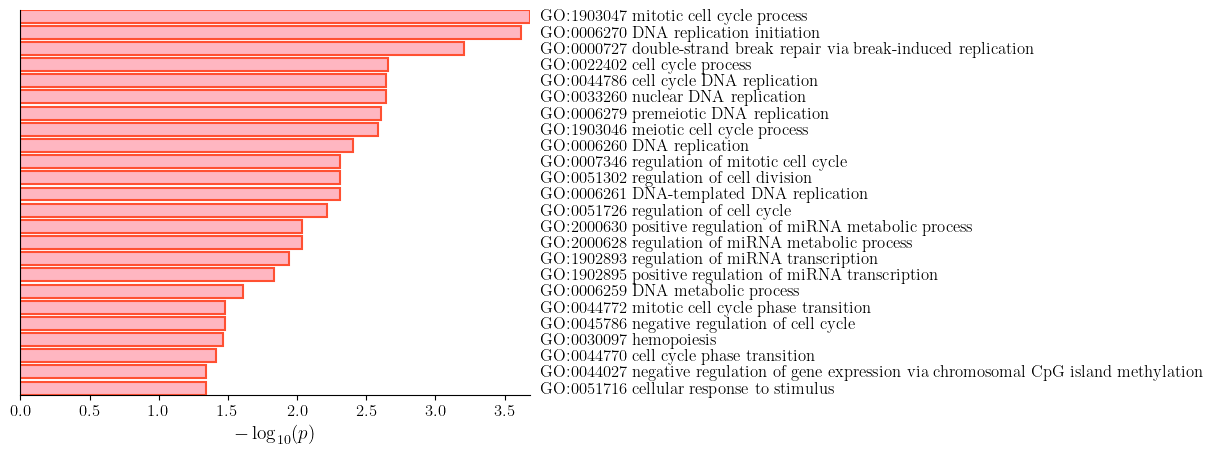

In [13]:
fig, ax = plt.subplots(nrows=1, ncols=1)
plt.barh(bp_results.index, bp_results.values, facecolor=bt.sct.pl.get_color("pink"), edgecolor=bt.sct.pl.get_color("red"), linewidth=1.5)
ax.yaxis.set_label_position("right")
ax.yaxis.tick_right()
ax.set_xlabel(r'$-\log_{10}(p)$')
plt.gca().invert_yaxis()
plt.tight_layout()
fig.set_size_inches(12, 5)
fig.subplots_adjust(right=0.55)
ax.yaxis.set_ticks_position('none')
plt.show()

In [15]:
def get_genes_from_go(go, go2gene, go_dag):
    genes = set()
    visited = set()

    if isinstance(go, str):
        to_visit = [go]
    elif isinstance(go, (set, tuple, list)):
        to_visit = list(go)
    else:
        raise TypeError

    while to_visit:
        current = to_visit.pop()

        if current in visited:
            continue

        if current in go2gene:
            genes.update(go2gene[current])

        if current in go_dag:
            children = go_dag[current].get_all_children()
            to_visit.extend(child for child in children if child not in visited)

        visited.add(current)

    return genes

gene2go = pd.read_csv("data/public/go/gene2go", sep="\t")
gene2go = gene2go[gene2go["#tax_id"] == 10090]
gene2go["gene"] = genesyn(list(gene2go["GeneID"].astype(str)), input_identifier_type="gene_id", output_identifier_type="official_name")
# gene2go = gene2go.loc[gene2go["gene"].isin(background)]

go2gene = (
    gene2go.groupby("GO_ID")["gene"]
    .apply(lambda x: list(set(x)))
    .to_dict()
)

In [99]:
hematopoiesis_markers = set(get_genes_from_go(["GO:0030097"], go2gene, go_dag))
print(f"hematopoiesis marker size: {len(hematopoiesis_markers)}")

hematopoiesis marker size: 204


In [100]:
hematopoiesis_number = {}
for k, v in genes.items():
    hematopoiesis_number[k] = len(hematopoiesis_markers & v)

In [101]:
hematopoiesis_number

{'Collombet': 5,
 'Hamey': 16,
 'Moignard': 9,
 'scBridge': 18,
 'Chevalier': 17,
 'scBridge-conn': 8}

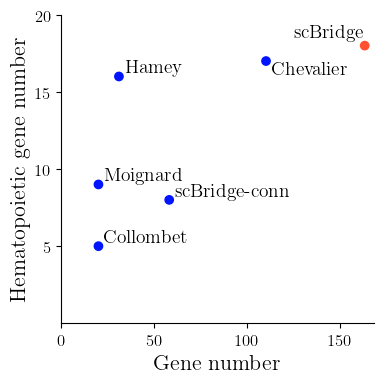

In [102]:
# Absolute hematopoietic gene recovery across models

x = [len(gene) for gene in genes.values()]
y = hematopoiesis_number.values()

colors = [
    bt.sct.pl.get_color("red") if model == "scBridge" else bt.sct.pl.get_color("blue")
    for model in hematopoiesis_number.keys()
]

fig, ax = plt.subplots(figsize=(4, 4))

ax.scatter(
    x,
    y,
    c=colors,
    alpha=1
)

for k, xi, yi in zip(hematopoiesis_number.keys(), x, y):
    if k == "scBridge":
        ax.text(
            xi,
            yi+0.3,
            k,
            fontsize=14,
            ha="right",
            va="bottom"
        )
    else:
        ax.text(
            xi + 3,
            yi,
            k,
            fontsize=14,
            ha="left",
            va="bottom" if k != "Chevalier" else "top"
        )

ax.set_xlim(0, max(x) + 5)
ax.set_ylim(0, max(y) + 2)
ax.set_yticks([5, 10, 15, 20])

ax.set_xlabel("Gene number", fontsize=16)
ax.set_ylabel("Hematopoietic gene number", fontsize=16)

plt.tight_layout()
plt.show()
#plt.savefig(
#    "hematopoietic_gene_recovery.pdf",
#    dpi=300,
#    bbox_inches="tight"
#)
plt.close()

In [186]:
import graphviz

connected = set()
for target, formula in bn.items():
    for node in bn:
        if not bn[node] in [bn.ba.FALSE, bn.ba.TRUE]:
            connected.add(node)
bn_filtered = {
    node: bn[node]
    for node in connected
    if node in bn
}
_dot = bt.bpy.bn_to_pydot(bn_filtered)
_dot.set("ratio", "compress")
_dot.set("size", "10,10!")
_dot.set("overlap", "prism")
_dot.set("sep", "+0")
_dot.set("esep", "+0")
_dot.set("K", "0.35")
_dot.set("pack", "true")
_dot.set("rankdir", "TB")
_dot.set("splines", "ortho")
#_dot.set("packmode", "graph")
for node in _dot.get_nodes():
    node.set_fontsize("14")
_dot.write_pdf("min_compact.pdf", prog="dot")
#_dot.write("min.pdf", prog="dot", format="pdf")
